# Original Dataframe

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/home/maiconkevyn/PycharmProjects/txt2sql_claude/data/CID-10-CAPITULOS.csv', sep=';')
df.head(20)

,NUMCAP,CATINIC,CATFIM,DESCRICAO,DESCRABREV,Unnamed: 5
0,1,A00,B99,Capitulo I - Algumas Doenças infecciosas e par...,I. Algumas Doenças infecciosas e parasitárias,NaN
1,2,C00,D48,Capitulo II - Neoplasias [tumores],II. Neoplasias (tumores),NaN
2,3,D50,D89,Capitulo III - Doenças do sangue e dos órgãos...,III. Doenças sangue órgãos hemat e transt imun...,NaN
3,4,E00,E90,"Capitulo IV - Doenças endócrinas, nutricionais...",IV. Doenças endócrinas nutricionais e metaból...,NaN
4,5,F00,F99,Capitulo V - Transtornos mentais e comportamen...,V. Transtornos mentais e comportamentais,NaN
5,6,G00,G99,Capitulo VI - Doenças do sistema nervoso,VI. Doenças do sistema nervoso,NaN
6,7,H00,H59,Capitulo VII - Doenças do olho e anexos,VII. Doenças do olho e anexos,NaN
7,8,H60,H95,Capitulo VIII - Doenças do ouvido e da apófise...,VIII.Doenças do ouvido e da apófise mastóide,NaN
8,9,I00,I99,Capitulo IX - Doenças do aparelho circulatório,IX. Doenças do aparelho circulatório,NaN
9,10,J00,J99,Capitulo X - Doenças do aparelho respiratório,X. Doenças do aparelho respiratório,NaN


In [3]:
df['CID_GERAL'] = df['CATINIC'].str[0]
df.head(20)

,NUMCAP,CATINIC,CATFIM,DESCRICAO,DESCRABREV,Unnamed: 5,CID_GERAL
0,1,A00,B99,Capitulo I - Algumas Doenças infecciosas e par...,I. Algumas Doenças infecciosas e parasitárias,NaN,A
1,2,C00,D48,Capitulo II - Neoplasias [tumores],II. Neoplasias (tumores),NaN,C
2,3,D50,D89,Capitulo III - Doenças do sangue e dos órgãos...,III. Doenças sangue órgãos hemat e transt imun...,NaN,D
3,4,E00,E90,"Capitulo IV - Doenças endócrinas, nutricionais...",IV. Doenças endócrinas nutricionais e metaból...,NaN,E
4,5,F00,F99,Capitulo V - Transtornos mentais e comportamen...,V. Transtornos mentais e comportamentais,NaN,F
5,6,G00,G99,Capitulo VI - Doenças do sistema nervoso,VI. Doenças do sistema nervoso,NaN,G
6,7,H00,H59,Capitulo VII - Doenças do olho e anexos,VII. Doenças do olho e anexos,NaN,H
7,8,H60,H95,Capitulo VIII - Doenças do ouvido e da apófise...,VIII.Doenças do ouvido e da apófise mastóide,NaN,H
8,9,I00,I99,Capitulo IX - Doenças do aparelho circulatório,IX. Doenças do aparelho circulatório,NaN,I
9,10,J00,J99,Capitulo X - Doenças do aparelho respiratório,X. Doenças do aparelho respiratório,NaN,J


In [4]:
df.drop(columns=['Unnamed: 5'], inplace=True)

# Dados SUS

In [5]:
dados_sus = pd.read_csv('/home/maiconkevyn/PycharmProjects/txt2sql_claude/data/dados_sus3.csv', sep=',')

dados_sus.head()

,DIAG_PRINC,MUNIC_RES,MUNIC_MOV,PROC_REA,IDADE,SEXO,CID_MORTE,MORTE,CNES,VAL_TOT,UTI_MES_TO,DT_INTER,DT_SAIDA,total_ocorrencias,UF_RESIDENCIA_PACIENTE,CIDADE_RESIDENCIA_PACIENTE,LATI_CIDADE_RES,LONG_CIDADE_RES
0,A46,430300,430300,303080078,67,3,0,0,2266474,292.62,0,20170803,20170808,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921
1,C168,430300,430300,304100021,60,1,0,0,2266474,797.11,0,20170803,20170805,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921
2,J128,430300,430300,303140151,76,3,0,1,2266474,4987.52,8,20170726,20170803,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921
3,I500,430300,430300,303060212,62,1,0,1,2266474,2702.50,4,20170802,20170805,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921
4,I158,430300,430300,303060107,29,3,0,0,2266474,1737.69,2,20170804,20170810,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921


In [6]:
media_idade_poa = dados_sus[dados_sus.CIDADE_RESIDENCIA_PACIENTE == 'Porto Alegre'].IDADE.mean()
media_idade_poa

#Qual é a idade media das pessoas de Porto Alegre?

np.float64(46.597214326321776)

In [7]:
media_idade_poa = dados_sus[dados_sus.CIDADE_RESIDENCIA_PACIENTE == 'Porto Alegre'].IDADE.mean()
print(f"A média de idade dos pacientes de Porto Alegre é: {media_idade_poa:.2f} anos")

A média de idade dos pacientes de Porto Alegre é: 46.60 anos


In [8]:
dados_sus[(dados_sus.MORTE==1) & (dados_sus.IDADE>40)].shape
#Qual sao os 3 municipios com mais mortes de pessoas com menos de 30 anos?

(1886, 18)

In [9]:
dados_sus[(dados_sus.MORTE==1) & (dados_sus.IDADE>40)].CIDADE_RESIDENCIA_PACIENTE.value_counts()
#Qual sao os 3 municipios com mais mortes de pessoas com menos de 30 anos?

CIDADE_RESIDENCIA_PACIENTE
Ijuí                           307
Uruguaiana                     296
Passo Fundo                    279
Porto Alegre                   266
Pelotas                        226
Caxias do Sul                  186
Santa Maria                    173
Santa Cruz do Sul - Lajeado    153
Name: count, dtype: int64

In [10]:
dados_sus[(dados_sus.MORTE==1) & (dados_sus.SEXO==1)].CIDADE_RESIDENCIA_PACIENTE.value_counts()
#Qual é o municipio onde morrem mais homens?Iju

CIDADE_RESIDENCIA_PACIENTE
Ijuí                           212
Uruguaiana                     186
Passo Fundo                    184
Porto Alegre                   170
Pelotas                        143
Caxias do Sul                  127
Santa Maria                    112
Santa Cruz do Sul - Lajeado    102
Name: count, dtype: int64

In [11]:
dados_sus[(dados_sus.MORTE==1) & (dados_sus.SEXO==3)].IDADE.mean()

np.float64(65.25569358178053)

In [12]:
dados_sus[(dados_sus.MORTE==1) & (dados_sus.IDADE<30)].CIDADE_RESIDENCIA_PACIENTE.value_counts()

CIDADE_RESIDENCIA_PACIENTE
Uruguaiana                     40
Ijuí                           32
Porto Alegre                   27
Passo Fundo                    26
Santa Maria                    24
Caxias do Sul                  20
Santa Cruz do Sul - Lajeado    17
Pelotas                        14
Name: count, dtype: int64

In [13]:
dados_sus[(dados_sus.MORTE==1) & (dados_sus.IDADE<40)& (dados_sus.SEXO==3)].CIDADE_RESIDENCIA_PACIENTE.value_counts()

CIDADE_RESIDENCIA_PACIENTE
Uruguaiana                     30
Porto Alegre                   17
Ijuí                           15
Passo Fundo                    15
Caxias do Sul                  14
Santa Maria                    12
Pelotas                         8
Santa Cruz do Sul - Lajeado     7
Name: count, dtype: int64

In [14]:
dados_sus[dados_sus.MORTE==1].DT_INTER.value_counts()

DT_INTER
20170803    11
20170729    11
20170802    10
20170726     8
20170720     8
            ..
20240209     1
20240304     1
20240125     1
20240319     1
20240216     1
Name: count, Length: 1359, dtype: int64

# Casos J

In [15]:
casos_j = dados_sus[dados_sus['DIAG_PRINC'].str.startswith('J')]

In [16]:
casos_j.shape

(2785, 18)

In [44]:
casos_j[casos_j.IDADE>30].shape

(1636, 18)

In [45]:
# Análise de mortes em 2018
print("Verificando estrutura dos dados de data:")
print(dados_sus['DT_INTER'].dtype)
print("\nAmostras de datas:")
print(dados_sus['DT_INTER'].head(10))

# Converter DT_INTER para datetime se necessário
dados_sus['DT_INTER'] = pd.to_datetime(dados_sus['DT_INTER'], errors='coerce')

# Extrair ano da data de internação
dados_sus['ANO'] = dados_sus['DT_INTER'].dt.year

print("\nAnos disponíveis nos dados:")
print(dados_sus['ANO'].value_counts().sort_index())

Verificando estrutura dos dados de data:
int64

Amostras de datas:
0    20170803
1    20170803
2    20170726
3    20170802
4    20170804
5    20170726
6    20170801
7    20170801
8    20170803
9    20170806
Name: DT_INTER, dtype: int64

Anos disponíveis nos dados:
ANO
1970    58655
Name: count, dtype: int64


In [48]:
dados_sus

,DIAG_PRINC,MUNIC_RES,MUNIC_MOV,PROC_REA,IDADE,SEXO,CID_MORTE,MORTE,CNES,VAL_TOT,UTI_MES_TO,DT_INTER,DT_SAIDA,total_ocorrencias,UF_RESIDENCIA_PACIENTE,CIDADE_RESIDENCIA_PACIENTE,LATI_CIDADE_RES,LONG_CIDADE_RES,ANO
0,A46,430300,430300,303080078,67,3,0,0,2266474,292.62,0,1970-01-01 00:00:00.020170803,20170808,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921,1970
1,C168,430300,430300,304100021,60,1,0,0,2266474,797.11,0,1970-01-01 00:00:00.020170803,20170805,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921,1970
2,J128,430300,430300,303140151,76,3,0,1,2266474,4987.52,8,1970-01-01 00:00:00.020170726,20170803,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921,1970
3,I500,430300,430300,303060212,62,1,0,1,2266474,2702.50,4,1970-01-01 00:00:00.020170802,20170805,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921,1970
4,I158,430300,430300,303060107,29,3,0,0,2266474,1737.69,2,1970-01-01 00:00:00.020170804,20170810,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921,1970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58650,M869,430460,430460,201010330,45,1,,0,3508528,212.26,0,1970-01-01 00:00:00.020140106,20140416,116612,Rio Grande do Sul,Uruguaiana,-29.756073,-57.086755,1970
58651,S029,430460,430460,404030033,58,1,,0,3508528,1875.40,0,1970-01-01 00:00:00.020140114,20140116,116612,Rio Grande do Sul,Uruguaiana,-29.756073,-57.086755,1970
58652,S027,430645,430460,404020542,69,1,,0,3626245,355.15,0,1970-01-01 00:00:00.020140221,20140222,1800,Rio Grande do Sul,Passo Fundo,-28.255060,-52.396661,1970
58653,S823,430690,430460,408050608,37,1,,0,3626245,1695.42,0,1970-01-01 00:00:00.020140302,20140314,8956,Rio Grande do Sul,Passo Fundo,-28.255060,-52.396661,1970


In [47]:
# Filtrar mortes em 2018
mortes_2018 = dados_sus[(dados_sus['MORTE'] == 1) & (dados_sus['ANO'] == 2017)]

print(f"Número total de mortes em 2018: {len(mortes_2018)}")
print(f"Porcentagem de mortes em 2018: {len(mortes_2018) / len(dados_sus[dados_sus['ANO'] == 2018]) * 100:.2f}%")

Número total de mortes em 2018: 0


ZeroDivisionError: division by zero

In [ ]:
# Estatísticas detalhadas das mortes em 2018
print("=== ANÁLISE DE MORTES EM 2018 ===")
print(f"Total de registros em 2018: {len(dados_sus[dados_sus['ANO'] == 2018])}")
print(f"Total de mortes em 2018: {len(mortes_2018)}")
print(f"Taxa de mortalidade: {len(mortes_2018) / len(dados_sus[dados_sus['ANO'] == 2018]) * 100:.2f}%")

print("\n=== DISTRIBUIÇÃO POR SEXO ===")
print(mortes_2018['SEXO'].value_counts())

print("\n=== DISTRIBUIÇÃO POR IDADE ===")
print(f"Idade média dos óbitos: {mortes_2018['IDADE'].mean():.2f} anos")
print(f"Idade mediana dos óbitos: {mortes_2018['IDADE'].median():.2f} anos")
print(f"Idade mínima: {mortes_2018['IDADE'].min()} anos")
print(f"Idade máxima: {mortes_2018['IDADE'].max()} anos")

In [18]:
casos_j[casos_j.SEXO==3].CIDADE_RESIDENCIA_PACIENTE.value_counts()

CIDADE_RESIDENCIA_PACIENTE
Passo Fundo                    194
Uruguaiana                     192
Ijuí                           182
Porto Alegre                   150
Caxias do Sul                  143
Pelotas                        142
Santa Cruz do Sul - Lajeado    113
Santa Maria                    104
Name: count, dtype: int64

In [19]:
casos_j[casos_j.CIDADE_RESIDENCIA_PACIENTE == 'Porto Alegre'].IDADE.mean()

np.float64(42.12394366197183)

In [20]:
casos_j

,DIAG_PRINC,MUNIC_RES,MUNIC_MOV,PROC_REA,IDADE,SEXO,CID_MORTE,MORTE,CNES,VAL_TOT,UTI_MES_TO,DT_INTER,DT_SAIDA,total_ocorrencias,UF_RESIDENCIA_PACIENTE,CIDADE_RESIDENCIA_PACIENTE,LATI_CIDADE_RES,LONG_CIDADE_RES
2,J128,430300,430300,303140151,76,3,0,1,2266474,4987.52,8,20170726,20170803,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921
6,J068,430300,430300,303140100,4,1,0,0,2266474,193.07,0,20170801,20170803,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921
8,J459,430300,430300,303140046,2,1,0,0,2266474,529.87,0,20170803,20170807,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921
34,J984,430300,430300,412030012,55,1,0,0,2266474,2273.43,0,20170810,20170813,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921
50,J210,430300,430300,303140143,4,3,0,0,2266474,211.13,0,20170726,20170729,24485,Rio Grande do Sul,Santa Maria,-29.686051,-53.806921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58539,J984,430410,431410,412030012,75,1,0000,0,2246988,2382.74,0,20150818,20150825,915,Rio Grande do Sul,Uruguaiana,-29.756073,-57.086755
58606,J852,430545,432160,303140038,20,1,0000,0,2793008,5726.31,10,20150906,20150924,4290,Rio Grande do Sul,Ijuí,-28.387873,-53.920169
58608,J343,430463,430463,404010415,67,1,0000,0,2707969,323.65,0,20151019,20151020,15291,Rio Grande do Sul,Uruguaiana,-29.756073,-57.086755
58634,J342,430210,430210,404010520,65,1,0000,0,2241021,213.75,0,20151021,20151022,25561,Rio Grande do Sul,Pelotas,-31.769974,-52.341016


In [21]:
casos_j[casos_j.SEXO==3].CIDADE_RESIDENCIA_PACIENTE.value_counts()

CIDADE_RESIDENCIA_PACIENTE
Passo Fundo                    194
Uruguaiana                     192
Ijuí                           182
Porto Alegre                   150
Caxias do Sul                  143
Pelotas                        142
Santa Cruz do Sul - Lajeado    113
Santa Maria                    104
Name: count, dtype: int64

In [22]:
casos_j.CIDADE_RESIDENCIA_PACIENTE.value_counts()

CIDADE_RESIDENCIA_PACIENTE
Ijuí                           433
Passo Fundo                    420
Uruguaiana                     407
Porto Alegre                   355
Caxias do Sul                  329
Pelotas                        314
Santa Cruz do Sul - Lajeado    287
Santa Maria                    240
Name: count, dtype: int64

In [23]:
casos_j[(casos_j.MORTE==1) & (casos_j.SEXO==3)].shape


(101, 18)

In [24]:
casos_j[(casos_j.MORTE==1) & (casos_j.SEXO==3) & (casos_j.IDADE >50)].shape

(79, 18)

In [25]:
casos_j[(casos_j.SEXO==3) & (casos_j.IDADE <30)].shape

(471, 18)

In [26]:
casos_j[(casos_j.SEXO==3) & (casos_j.IDADE <30) & (casos_j.MORTE==1)].shape

(8, 18)

In [27]:
casos_j[(casos_j.MORTE==1) & (casos_j.SEXO==3) & (casos_j.IDADE <30)].CIDADE_RESIDENCIA_PACIENTE.value_counts()

CIDADE_RESIDENCIA_PACIENTE
Uruguaiana      4
Pelotas         2
Porto Alegre    1
Passo Fundo     1
Name: count, dtype: int64

In [28]:
casos_j.CIDADE_RESIDENCIA_PACIENTE.value_counts()

CIDADE_RESIDENCIA_PACIENTE
Ijuí                           433
Passo Fundo                    420
Uruguaiana                     407
Porto Alegre                   355
Caxias do Sul                  329
Pelotas                        314
Santa Cruz do Sul - Lajeado    287
Santa Maria                    240
Name: count, dtype: int64

In [29]:
# casos_j = casos_j[(casos_j.SEXO==1) & (casos_j.MORTE==1)]

In [30]:
# casos_j = casos_j[casos_j.MORTE==1]

In [31]:
casos_j.CIDADE_RESIDENCIA_PACIENTE.value_counts()

CIDADE_RESIDENCIA_PACIENTE
Ijuí                           433
Passo Fundo                    420
Uruguaiana                     407
Porto Alegre                   355
Caxias do Sul                  329
Pelotas                        314
Santa Cruz do Sul - Lajeado    287
Santa Maria                    240
Name: count, dtype: int64

In [32]:
casos_j.columns

Index(['DIAG_PRINC', 'MUNIC_RES', 'MUNIC_MOV', 'PROC_REA', 'IDADE', 'SEXO',
       'CID_MORTE', 'MORTE', 'CNES', 'VAL_TOT', 'UTI_MES_TO', 'DT_INTER',
       'DT_SAIDA', 'total_ocorrencias', 'UF_RESIDENCIA_PACIENTE',
       'CIDADE_RESIDENCIA_PACIENTE', 'LATI_CIDADE_RES', 'LONG_CIDADE_RES'],
      dtype='object')

In [33]:
dados_sus[(dados_sus.SEXO==1) & (dados_sus.MORTE==1)].CIDADE_RESIDENCIA_PACIENTE.value_counts()

CIDADE_RESIDENCIA_PACIENTE
Ijuí                           212
Uruguaiana                     186
Passo Fundo                    184
Porto Alegre                   170
Pelotas                        143
Caxias do Sul                  127
Santa Maria                    112
Santa Cruz do Sul - Lajeado    102
Name: count, dtype: int64

In [34]:
casos_jan_abr_2017 = casos_j[(casos_j['DT_INTER'].astype(str) >= '20190101') &
                             (casos_j['DT_INTER'].astype(str) <= '20191231')]
# Contando o número total de casos nesse período
total_casos = len(casos_jan_abr_2017)
total_casos

202

In [35]:
casos_jan_abr_2017 = dados_sus[(dados_sus['DT_INTER'].astype(str) >= '20190101') &
                             (dados_sus['DT_INTER'].astype(str) <= '20191231')]

# Contando o número total de casos nesse período
total_casos = len(casos_jan_abr_2017)
total_casos

4711

In [36]:
# Calculando o tempo médio de internação usando DT_SAIDA e DT_INTER
# Primeiro, convertemos as colunas para datetime
import pandas as pd
from datetime import datetime

# Convertendo colunas para datetime
casos_j['DT_INTER_DATE'] = pd.to_datetime(casos_j['DT_INTER'].astype(str), format='%Y%m%d', errors='coerce')
casos_j['DT_SAIDA_DATE'] = pd.to_datetime(casos_j['DT_SAIDA'].astype(str), format='%Y%m%d', errors='coerce')

# Calculando a diferença em dias
casos_j['TEMPO_INTERNACAO'] = (casos_j['DT_SAIDA_DATE'] - casos_j['DT_INTER_DATE']).dt.days

# Filtrando apenas registros com tempo de internação válido (positivo)
casos_validos = casos_j[casos_j['TEMPO_INTERNACAO'] >= 0].copy()

# Calculando estatísticas do tempo de internação
tempo_medio = casos_validos['TEMPO_INTERNACAO'].mean()

print(f"Tempo médio de internação: {tempo_medio:.2f} dias")





Tempo médio de internação: 6.09 dias


/tmp/ipykernel_133900/3223882074.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  casos_j['DT_INTER_DATE'] = pd.to_datetime(casos_j['DT_INTER'].astype(str), format='%Y%m%d', errors='coerce')
/tmp/ipykernel_133900/3223882074.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  casos_j['DT_SAIDA_DATE'] = pd.to_datetime(casos_j['DT_SAIDA'].astype(str), format='%Y%m%d', errors='coerce')
/tmp/ipykernel_133900/3223882074.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [37]:
casos_j = dados_sus[dados_sus['DIAG_PRINC'].str.startswith('J')]
casos_j.shape

(2785, 18)

In [38]:
dados_sus= dados_sus[(dados_sus.SEXO==1)&(dados_sus.MORTE==1) & (dados_sus.IDADE <30)]
dados_sus.shape

(116, 18)

In [39]:
Qual é o município onde morrem mais pessoas com menos de 30 anos?

Object `anos` not found.


In [40]:
Quais são as 5 cidades com o maior numero de mortes e quantas mortes foram em cada uma?

Object `uma` not found.


📊 ANÁLISE DE MORTES POR ANO
🏆 NÚMERO DE MORTES POR ANO:
------------------------------
2017: 400 mortes
2021: 384 mortes
2023: 275 mortes
2020: 193 mortes
2022: 186 mortes
2014: 184 mortes
2019: 152 mortes
2024: 136 mortes
2015: 127 mortes
2016: 73 mortes
2018: 62 mortes
2013: 30 mortes

✅ RESPOSTA: O ano com maior número de mortes foi 2017 com 400 mortes


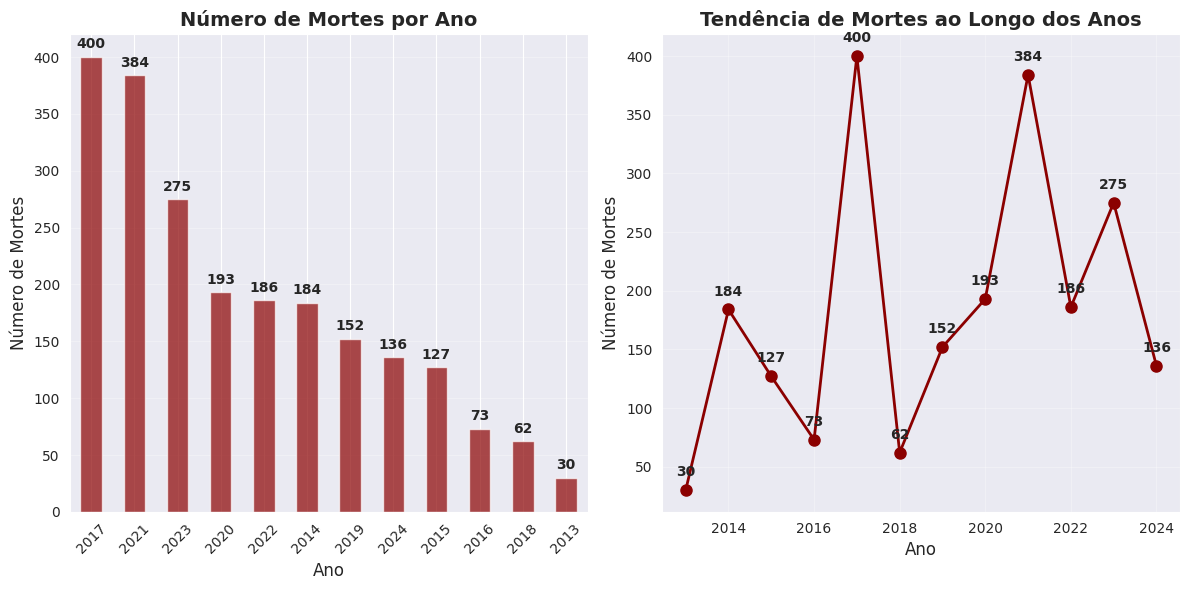


📈 ESTATÍSTICAS DETALHADAS:
Total de mortes no dataset: 2202
Período analisado: 2013 - 2024
Média de mortes por ano: 183.5
Ano com mais mortes: 2017 (400 mortes)
Ano com menos mortes: 2013 (30 mortes)

🔧 VALIDAÇÃO (usando lógica DT_INTER//10000):
Exemplo de conversão: DT_INTER=20170803 → ANO=2017
Confirmação: {2017: 400}


In [41]:
# Análise de Mortes por Ano
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Primeiro, vamos recarregar o dataset original para ter dados limpos
dados_sus = pd.read_csv('/home/maiconkevyn/PycharmProjects/txt2sql_claude/data/dados_sus3.csv', sep=',')

print("📊 ANÁLISE DE MORTES POR ANO")
print("=" * 50)

# Extrair ano da data de internação usando a mesma lógica do sistema: DT_INTER // 10000
dados_sus['ANO'] = dados_sus['DT_INTER'] // 10000

# Filtrar apenas casos de morte (MORTE = 1)
mortes = dados_sus[dados_sus['MORTE'] == 1]

# Contar mortes por ano
mortes_por_ano = mortes.groupby('ANO').size().sort_values(ascending=False)

print("🏆 NÚMERO DE MORTES POR ANO:")
print("-" * 30)
for ano, total in mortes_por_ano.items():
    print(f"{ano}: {total} mortes")

print(f"\n✅ RESPOSTA: O ano com maior número de mortes foi {mortes_por_ano.index[0]} com {mortes_por_ano.iloc[0]} mortes")

# Criar visualização
plt.figure(figsize=(12, 6))

# Gráfico de barras
plt.subplot(1, 2, 1)
mortes_por_ano.plot(kind='bar', color='darkred', alpha=0.7)
plt.title('Número de Mortes por Ano', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número de Mortes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores no topo das barras
for i, v in enumerate(mortes_por_ano.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

# Gráfico de linha para tendência
plt.subplot(1, 2, 2)
mortes_por_ano_ordenado = mortes_por_ano.sort_index()
plt.plot(mortes_por_ano_ordenado.index, mortes_por_ano_ordenado.values, 
         marker='o', linewidth=2, markersize=8, color='darkred')
plt.title('Tendência de Mortes ao Longo dos Anos', fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número de Mortes', fontsize=12)
plt.grid(True, alpha=0.3)

# Adicionar valores nos pontos
for x, y in zip(mortes_por_ano_ordenado.index, mortes_por_ano_ordenado.values):
    plt.annotate(str(y), (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Estatísticas adicionais
print(f"\n📈 ESTATÍSTICAS DETALHADAS:")
print(f"Total de mortes no dataset: {len(mortes)}")
print(f"Período analisado: {mortes_por_ano.sort_index().index[0]} - {mortes_por_ano.sort_index().index[-1]}")
print(f"Média de mortes por ano: {mortes_por_ano.mean():.1f}")
print(f"Ano com mais mortes: {mortes_por_ano.index[0]} ({mortes_por_ano.iloc[0]} mortes)")
print(f"Ano com menos mortes: {mortes_por_ano.index[-1]} ({mortes_por_ano.iloc[-1]} mortes)")

# Validar com a mesma lógica usada no sistema SQL
print(f"\n🔧 VALIDAÇÃO (usando lógica DT_INTER//10000):")
print(f"Exemplo de conversão: DT_INTER=20170803 → ANO={20170803//10000}")
print(f"Confirmação: {mortes_por_ano.sort_values(ascending=False).head(1).to_dict()}")

In [42]:
# Análise Comparativa: Sistema SQL vs Pandas
print("🔍 VALIDAÇÃO CRUZADA: SQL vs PANDAS")
print("=" * 50)

# Simular a mesma query SQL que o sistema usa:
# SELECT DT_INTER/10000 AS ano, COUNT(*) as total_mortes 
# FROM sus_data WHERE MORTE = 1 
# GROUP BY ano ORDER BY total_mortes DESC LIMIT 1;

mortes_dados = dados_sus[dados_sus['MORTE'] == 1].copy()
mortes_dados['ano_sql'] = mortes_dados['DT_INTER'] // 10000  # Mesma lógica SQL
resultado_sql_like = mortes_dados.groupby('ano_sql').size().sort_values(ascending=False).head(1)

print("🤖 RESULTADO SIMULANDO SQL:")
ano_sql = resultado_sql_like.index[0]
total_sql = resultado_sql_like.iloc[0]
print(f"ano: {ano_sql}, total_mortes: {total_sql}")

print("\n🐍 RESULTADO PANDAS (método anterior):")
print(f"ano: {mortes_por_ano.index[0]}, total_mortes: {mortes_por_ano.iloc[0]}")

print(f"\n✅ VALIDAÇÃO: {'IDÊNTICOS' if ano_sql == mortes_por_ano.index[0] and total_sql == mortes_por_ano.iloc[0] else 'DIFERENTES'}")

# Mostrar distribuição completa
print(f"\n📊 DISTRIBUIÇÃO COMPLETA DE MORTES POR ANO:")
distribuicao_completa = mortes_dados.groupby('ano_sql').size().sort_index()
for ano, total in distribuicao_completa.items():
    percentage = (total / distribuicao_completa.sum()) * 100
    print(f"{ano}: {total:3d} mortes ({percentage:5.1f}%)")

# Análise de tendência
print(f"\n📈 ANÁLISE DE TENDÊNCIA:")
anos_ordenados = distribuicao_completa.sort_index()
if len(anos_ordenados) > 1:
    tendencia = "CRESCENTE" if anos_ordenados.iloc[-1] > anos_ordenados.iloc[0] else "DECRESCENTE"
    variacao = anos_ordenados.iloc[-1] - anos_ordenados.iloc[0]
    print(f"Tendência geral: {tendencia}")
    print(f"Variação total: {variacao:+d} mortes ({anos_ordenados.index[0]} → {anos_ordenados.index[-1]})")

# Identificar anos atípicos
media_mortes = distribuicao_completa.mean()
desvio_padrao = distribuicao_completa.std()
anos_atipicos = distribuicao_completa[(distribuicao_completa > media_mortes + desvio_padrao) | 
                                     (distribuicao_completa < media_mortes - desvio_padrao)]

if len(anos_atipicos) > 0:
    print(f"\n⚠️ ANOS ATÍPICOS (>1σ da média):")
    for ano, total in anos_atipicos.items():
        status = "ACIMA" if total > media_mortes else "ABAIXO"
        print(f"{ano}: {total} mortes ({status} da média)")
else:
    print(f"\n✅ Não há anos com variação significativa (todos dentro de 1σ)")

print(f"\nℹ️ Média: {media_mortes:.1f} ± {desvio_padrao:.1f} mortes/ano")

🔍 VALIDAÇÃO CRUZADA: SQL vs PANDAS
🤖 RESULTADO SIMULANDO SQL:
ano: 2017, total_mortes: 400

🐍 RESULTADO PANDAS (método anterior):
ano: 2017, total_mortes: 400

✅ VALIDAÇÃO: IDÊNTICOS

📊 DISTRIBUIÇÃO COMPLETA DE MORTES POR ANO:
2013:  30 mortes (  1.4%)
2014: 184 mortes (  8.4%)
2015: 127 mortes (  5.8%)
2016:  73 mortes (  3.3%)
2017: 400 mortes ( 18.2%)
2018:  62 mortes (  2.8%)
2019: 152 mortes (  6.9%)
2020: 193 mortes (  8.8%)
2021: 384 mortes ( 17.4%)
2022: 186 mortes (  8.4%)
2023: 275 mortes ( 12.5%)
2024: 136 mortes (  6.2%)

📈 ANÁLISE DE TENDÊNCIA:
Tendência geral: CRESCENTE
Variação total: +106 mortes (2013 → 2024)

⚠️ ANOS ATÍPICOS (>1σ da média):
2013: 30 mortes (ABAIXO da média)
2017: 400 mortes (ACIMA da média)
2018: 62 mortes (ABAIXO da média)
2021: 384 mortes (ACIMA da média)

ℹ️ Média: 183.5 ± 117.8 mortes/ano
